## End-to-End Artifact Workflow: Pretrained sklearn and Torch

This notebook demonstrates two full artifact pipelines that mirror canonical example configs:

1. sklearn pipeline from `examples/sklearn/config/default.yaml`
2. torch pipeline from `examples/pytorch/config/torch_default.yaml`

Each pipeline includes:

- pretrained model save/load,
- defense instantiation,
- attack generation,
- score and attack artifact persistence,
- plot creation and saving to disk.

In [1]:
import json
import pickle
from importlib import import_module
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
from hydra import compose, initialize_config_dir
from hydra.core.config_store import ConfigStore
from hydra.core.global_hydra import GlobalHydra
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from deckard.file import FileConfig
from deckard.plot import PlotConfig

ROOT = Path(".").resolve()
PROJECT_ROOT = Path("../..").resolve()
ARTIFACT_ROOT = ROOT / "build" / "notebook_artifacts"
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

def reset_hydra_state() -> None:
    if GlobalHydra.instance().is_initialized():
        GlobalHydra.instance().clear()
    config_store = ConfigStore.instance()
    for key in list(config_store.repo.keys()):
        if key not in {"hydra", "_dummy_empty_config_.yaml"}:
            config_store.repo.pop(key, None)

print("Artifact root:", ARTIFACT_ROOT)

/opt/hostedtoolcache/Python/3.10.20/arm64/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Artifact root: /Users/c.meyers/Documents/deckard/docs/notebooks/build/notebook_artifacts


## sklearn Pretrained Pipeline (Model + Defense + Attack + Plot)

This section composes the canonical sklearn default config (`model=rf`, `defense=class-labels`, `attack=hsj`), trains a model once, saves it as pretrained, reloads it, runs attack + defense through ART, and writes artifacts and plots.

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


...

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


sklearn model: rf | defense: class-labels | attack: hsj
sklearn artifacts: <deckard.file.FileConfig object at 0xfffed5216bf0>
sklearn plot: /Users/c.meyers/Documents/deckard/docs/notebooks/build/notebook_artifacts/sklearn/accuracy_clean_vs_adv.png


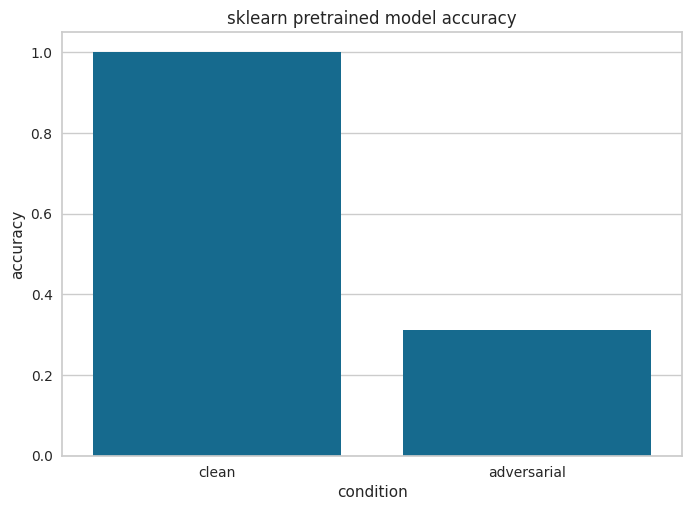

In [2]:
from art.estimators.classification.scikitlearn import ScikitlearnClassifier

sklearn_dir = ARTIFACT_ROOT / "sklearn"
sklearn_dir.mkdir(parents=True, exist_ok=True)
sklearn_files = FileConfig(
    data_file=str(sklearn_dir / "data.pkl"),
    model_file=str(sklearn_dir / "pretrained_model.pkl"),
    score_file=str(sklearn_dir / "scores.json"),
    attack_file=str(sklearn_dir / "attack.pkl"),
)

reset_hydra_state()
sklearn_cfg_dir = PROJECT_ROOT / "examples" / "sklearn" / "config"
with initialize_config_dir(version_base="1.3", config_dir=str(sklearn_cfg_dir)):
    sk_cfg = compose(config_name="default", overrides=["score=classification", "model=rf", "attack=hsj"] )

X, y = make_classification(
    n_samples=220,
    n_features=10,
    n_informative=6,
    n_redundant=0,
    random_state=13,
    class_sep=1.25,
    flip_y=0.02,
    weights=[0.55, 0.45],
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=7, stratify=y
)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model_module, model_class = sk_cfg.model.model_type.rsplit(".", 1)
SkModel = getattr(import_module(model_module), model_class)
sk_model = SkModel(**dict(sk_cfg.model.model_params))
sk_model.fit(X_train, y_train)

with open(sklearn_files.model_file, "wb") as f:
    pickle.dump(sk_model, f)

with open(sklearn_files.model_file, "rb") as f:
    pretrained_sk_model = pickle.load(f)

defense_module, defense_class = sk_cfg.defense.defense_name.rsplit(".", 1)
DefenseClass = getattr(import_module(defense_module), defense_class)
sk_defense = DefenseClass(**dict(sk_cfg.defense.defense_params))

art_sk = ScikitlearnClassifier(
    model=pretrained_sk_model,
    clip_values=(0.0, 1.0),
    postprocessing_defences=[sk_defense],
)

attack_module, attack_class = sk_cfg.attack.attack_type.rsplit(".", 1)
AttackClass = getattr(import_module(attack_module), attack_class)
hsj_params = dict(sk_cfg.attack.attack_params)
hsj_params.update({
    "max_iter": min(int(hsj_params.get("max_iter", 10)), 1),
    "max_eval": min(int(hsj_params.get("max_eval", 20)), 20),
    "init_eval": min(int(hsj_params.get("init_eval", 1)), 5),
    "init_size": min(int(hsj_params.get("init_size", 100)), 16),
    "verbose": False,
})
try:
    sk_attack = AttackClass(estimator=art_sk, **hsj_params)
except TypeError:
    sk_attack = AttackClass(classifier=art_sk, **hsj_params)

x_eval = X_test[:16]
y_eval = y_test[:16]
x_adv = sk_attack.generate(x=x_eval)

clean_acc = float(accuracy_score(y_eval, pretrained_sk_model.predict(x_eval)))
adv_acc = float(accuracy_score(y_eval, pretrained_sk_model.predict(x_adv)))

with open(sklearn_files.data_file, "wb") as f:
    pickle.dump({"x_train_shape": X_train.shape, "x_test_shape": X_test.shape}, f)
with open(sklearn_files.attack_file, "wb") as f:
    pickle.dump({"x_adv": x_adv, "attack_alias": sk_cfg.attack.alias}, f)
Path(sklearn_files.score_file).write_text(
    json.dumps({
        "clean_accuracy": clean_acc,
        "adversarial_accuracy": adv_acc,
        "defense_alias": sk_cfg.defense.alias,
        "attack_alias": sk_cfg.attack.alias,
    }, indent=2),
    encoding="utf-8",
)

sk_plot_path = sklearn_dir / "accuracy_clean_vs_adv.png"
sk_plot_csv = sklearn_dir / "accuracy_clean_vs_adv.csv"
pd.DataFrame(
    {
        "condition": ["clean", "adversarial"],
        "accuracy": [clean_acc, adv_acc],
    },
).to_csv(sk_plot_csv, index=False)
PlotConfig(
    kwargs={
        "data_file": str(sk_plot_csv),
        "x": "condition",
        "y": "accuracy",
        "plot_type": "bar",
        "title": "sklearn pretrained model accuracy",
        "plot_file": str(sk_plot_path),
    },
)()

print("sklearn model:", sk_cfg.model.alias, "| defense:", sk_cfg.defense.alias, "| attack:", sk_cfg.attack.alias)
print("sklearn artifacts:", sklearn_files)
print("sklearn plot:", sk_plot_path)

## torch Pretrained Pipeline (Model + Defense + Attack + Plot)

This section composes the canonical torch default config (`model=default`, `attack=fgm`) and uses a lightweight torch classifier to demonstrate pretrained save/load, ART attack + defense, artifact persistence, and plot generation.

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


...

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


torch model alias: torch_resnet18 | attack: fgm
torch artifacts: <deckard.file.FileConfig object at 0xfffed2596da0>
torch plots: /Users/c.meyers/Documents/deckard/docs/notebooks/build/notebook_artifacts/torch/training_loss.png and /Users/c.meyers/Documents/deckard/docs/notebooks/build/notebook_artifacts/torch/accuracy_clean_vs_adv.png


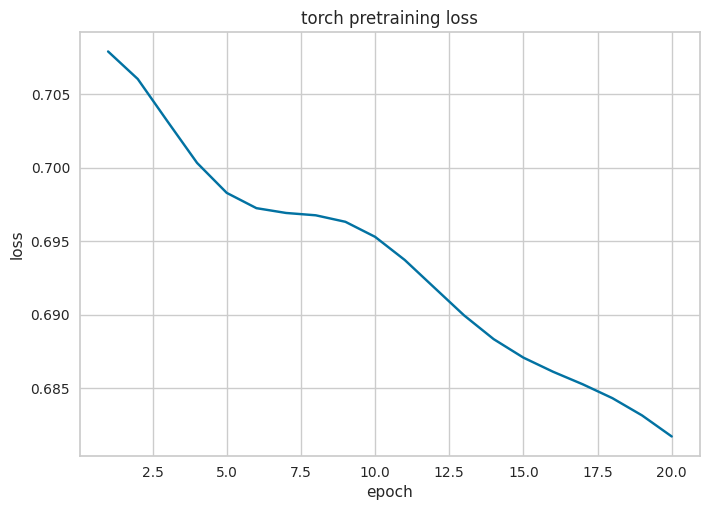

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


...

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


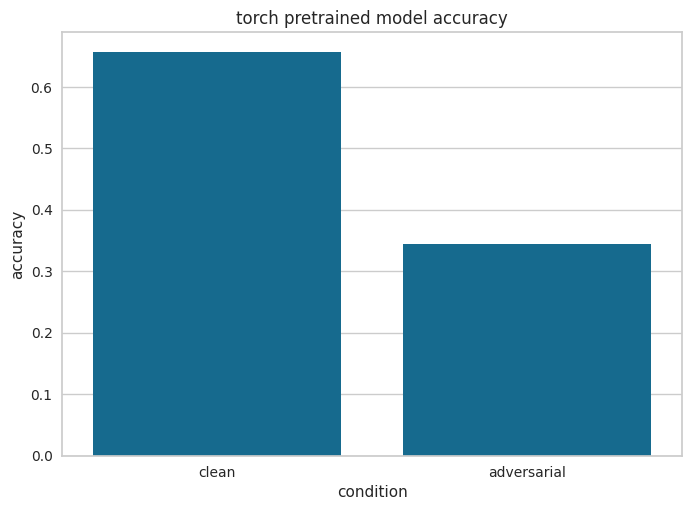

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from art.estimators.classification import PyTorchClassifier

torch_dir = ARTIFACT_ROOT / "torch"
torch_dir.mkdir(parents=True, exist_ok=True)
torch_files = FileConfig(
    data_file=str(torch_dir / "data.pkl"),
    model_file=str(torch_dir / "pretrained_model.pt"),
    score_file=str(torch_dir / "scores.json"),
    attack_file=str(torch_dir / "attack.pkl"),
)

reset_hydra_state()
torch_cfg_dir = PROJECT_ROOT / "examples" / "pytorch" / "config"
with initialize_config_dir(version_base="1.3", config_dir=str(torch_cfg_dir)):
    torch_cfg = compose(config_name="torch_default", overrides=["attack=fgm", "model=default"] )

torch_defense_yaml = PROJECT_ROOT / "examples" / "pytorch" / "config" / "defense" / "class_labels.yaml"
torch_defense_cfg = yaml.safe_load(torch_defense_yaml.read_text())
defense_module, defense_class = torch_defense_cfg["defense_name"].rsplit(".", 1)
TorchDefense = getattr(import_module(defense_module), defense_class)
torch_defense = TorchDefense(**dict(torch_defense_cfg.get("defense_params", {})))

X_t, y_t = make_classification(
    n_samples=320,
    n_features=20,
    n_informative=12,
    n_redundant=0,
    random_state=21,
    class_sep=1.1,
    flip_y=0.03,
    weights=[0.52, 0.48],
)
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_t, y_t, test_size=0.3, random_state=22, stratify=y_t
)
scaler_t = MinMaxScaler()
X_train_t = scaler_t.fit_transform(X_train_t).astype(np.float32)
X_test_t = scaler_t.transform(X_test_t).astype(np.float32)

x_train_tensor = torch.tensor(X_train_t, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_t, dtype=torch.long)

torch_model = nn.Sequential(
    nn.Linear(X_train_t.shape[1], 32),
    nn.ReLU(),
    nn.Linear(32, 2),
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(torch_model.parameters(), lr=0.05, momentum=0.9)
loss_history = []
for epoch in range(20):
    optimizer.zero_grad()
    logits = torch_model(x_train_tensor)
    loss = criterion(logits, y_train_tensor)
    loss.backward()
    optimizer.step()
    loss_history.append({"epoch": epoch + 1, "loss": float(loss.item())})

torch.save(torch_model.state_dict(), torch_files.model_file)

pretrained_torch_model = nn.Sequential(
    nn.Linear(X_train_t.shape[1], 32),
    nn.ReLU(),
    nn.Linear(32, 2),
)
pretrained_torch_model.load_state_dict(torch.load(torch_files.model_file, map_location="cpu"))
pretrained_torch_model.eval()

art_torch = PyTorchClassifier(
    model=pretrained_torch_model,
    loss=criterion,
    optimizer=optimizer,
    input_shape=(X_train_t.shape[1],),
    nb_classes=2,
    clip_values=(0.0, 1.0),
    postprocessing_defences=[torch_defense],
)

fgm_module, fgm_class = torch_cfg.attack.attack_type.rsplit(".", 1)
FGM = getattr(import_module(fgm_module), fgm_class)
fgm_params = dict(torch_cfg.attack.attack_params)
fgm_params.update({
    "eps": min(float(fgm_params.get("eps", 1.0)), 0.2),
    "eps_step": min(float(fgm_params.get("eps_step", 0.01)), 0.02),
    "batch_size": 16,
})
try:
    torch_attack = FGM(estimator=art_torch, **fgm_params)
except TypeError:
    torch_attack = FGM(classifier=art_torch, **fgm_params)

x_eval_t = X_test_t[:32]
y_eval_t = y_test_t[:32]

clean_pred_t = np.argmax(art_torch.predict(x_eval_t), axis=1)
x_adv_t = torch_attack.generate(x=x_eval_t)
adv_pred_t = np.argmax(art_torch.predict(x_adv_t), axis=1)

clean_acc_t = float((clean_pred_t == y_eval_t).mean())
adv_acc_t = float((adv_pred_t == y_eval_t).mean())

with open(torch_files.data_file, "wb") as f:
    pickle.dump({"x_train_shape": X_train_t.shape, "x_test_shape": X_test_t.shape}, f)
with open(torch_files.attack_file, "wb") as f:
    pickle.dump({"x_adv": x_adv_t, "attack_alias": torch_cfg.attack.alias}, f)
Path(torch_files.score_file).write_text(
    json.dumps({
        "clean_accuracy": clean_acc_t,
        "adversarial_accuracy": adv_acc_t,
        "defense_name": torch_defense_cfg["defense_name"],
        "attack_alias": torch_cfg.attack.alias,
    }, indent=2),
    encoding="utf-8",
)

torch_loss_plot = torch_dir / "training_loss.png"
torch_loss_csv = torch_dir / "training_loss.csv"
pd.DataFrame(loss_history).to_csv(torch_loss_csv, index=False)
PlotConfig(
    kwargs={
        "data_file": str(torch_loss_csv),
        "x": "epoch",
        "y": "loss",
        "plot_type": "line",
        "title": "torch pretraining loss",
        "plot_file": str(torch_loss_plot),
    },
)()

torch_acc_plot = torch_dir / "accuracy_clean_vs_adv.png"
torch_acc_csv = torch_dir / "accuracy_clean_vs_adv.csv"
pd.DataFrame(
    {
        "condition": ["clean", "adversarial"],
        "accuracy": [clean_acc_t, adv_acc_t],
    },
).to_csv(torch_acc_csv, index=False)
PlotConfig(
    kwargs={
        "data_file": str(torch_acc_csv),
        "x": "condition",
        "y": "accuracy",
        "plot_type": "bar",
        "title": "torch pretrained model accuracy",
        "plot_file": str(torch_acc_plot),
    },
)()

print("torch model alias:", torch_cfg.model.alias, "| attack:", torch_cfg.attack.alias)
print("torch artifacts:", torch_files)
print("torch plots:", torch_loss_plot, "and", torch_acc_plot)